In [16]:
import sklearn
import pandas as pd
import scipy
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import researchpy

In [17]:
filename = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\CS-3120-Project\GeneratedData\\DataAnalysisFinal"

df = pd.read_csv(filename)

# K-Modes Clustering 

First - replace all NaN data with "unknown" so it can be treated as its own value. The only exceptions are OTHER_VEH_SP and OTHER_VEH_AVG_WEIGHT since for those columns NaN represents "not applicable"

In [18]:
from kmodes.kmodes import KModes

In [19]:
#Create a clean df to apply changes to
df_clean = df.astype(str).replace('nan', 'Unknown').fillna('Unknown')

In [20]:
#Exclude case and vehicle numbers since they won't be included in clustering
df_clean = df_clean.drop(["ST_CASE", "VEH_NO"], axis=1)

In [21]:
#Create a numpy matrix from our df to be compatible with KModes

data_matrix = df_clean.to_numpy()

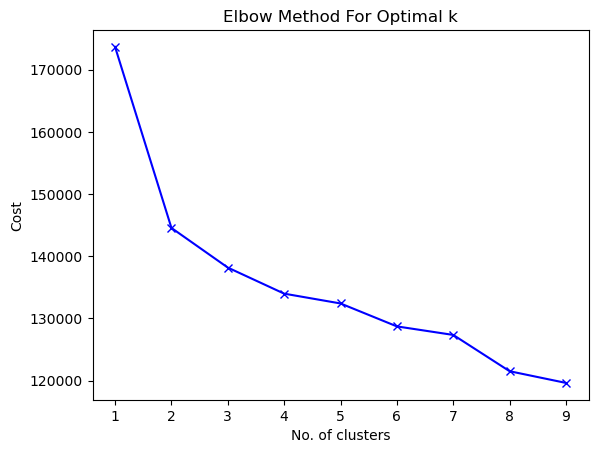

In [22]:
cost = []
K = range(1, 10)
for k in K:
    # init='Cao' is optimized for categorical density
    kmodes = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    kmodes.fit(data_matrix)
    cost.append(kmodes.cost_)

# Optional: Plot cost to pick K
import matplotlib.pyplot as plt
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()

I'm choosing 6 clusters as the line seems to flatten out substantially there

In [33]:
km = KModes(n_clusters=4, init='Cao', n_init=5, verbose=1)
clusters = km.fit_predict(data_matrix)
print(km.cluster_centroids_)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 7250, cost: 134293.0
Run 1, iteration: 2/100, moves: 969, cost: 133976.0
Run 1, iteration: 3/100, moves: 113, cost: 133976.0
[['2.0' 'Unknown' '0' '1.0' '0.0' '0.0' '2.0' '2' '2' 'evening rush'
  '1.0' '2.0' '4.0' '4.0' 'Unknown' '1.0' '1.0' '1' '1.0' '10.0'
  'Unknown' 'Unknown']
 ['2.0' 'Unknown' '1' '1.0' '0.0' '0.0' '1.0' '1' '1' 'evening' '2.0'
  '1.0' '7.0' '1.0' 'Unknown' '1.0' '1.0' '4' '1.0' '20.0' 'Unknown'
  'Unknown']
 ['2.0' 'Unknown' '0' '1.0' '0.0' '0.0' '2.0' '2' '2' 'evening rush'
  '1.0' '2.0' '3.0' '4.0' '6.0' '2.0' '2.0' '1' '1.0' '20.0' 'Unknown'
  '11.0']
 ['2.0' 'Unknown' '1' '1.0' '0.0' '0.0' '2.0' '2' '2' 'evening' '2.0'
  '1.0' '5.0' '4.0' '1.0' '1.0' '1.0' '1' '1.0' '20.0' 'Unknown' '11.0']]


In [34]:
df_clean['cluster'] = clusters

## Testing how differentiated the clusters are<br>
By testing the **Chi-Squared** contingencies of each feature against each cluster, we can determine which features are the most differentiated between clusters. This can help us define each cluster

In [36]:
from scipy.stats import chi2_contingency

In [37]:
#Generated by Gemini using the prompt: "Give a python function with generic inputs to conduct a Chi-Squared test for independence between...
#the cluster label and each of the features in a dataframe

def analyze_cluster_differentiation(df, cluster_labels, alpha=0.05):
    """
    Performs Chi-Squared tests to determine if features are significantly 
    differentiated across clusters.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The original categorical features (excluding the cluster label).
    cluster_labels : array-like
        The cluster assignments for each row (output from K-Modes).
    alpha : float
        The significance level (default 0.05).
        
    Returns:
    --------
    pd.DataFrame
        A summary table sorted by the strength of the relationship (Cramer's V).
    """
    
    results = []

    # Ensure inputs are aligned
    if len(df) != len(cluster_labels):
        raise ValueError("Length of DataFrame and Cluster Labels must match.")

    for column in df.columns:
        # 1. Create the Contingency Table (Observed Counts)
        # This counts how many times each category appears in each cluster
        contingency_table = pd.crosstab(df[column], cluster_labels)
        
        # 2. Perform Chi-Squared Test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # 3. Check Assumption (Cochran's Rule)
        # Check if more than 20% of expected counts are < 5
        low_expected_counts = (expected < 5).sum()
        total_cells = expected.size
        assumption_warning = (low_expected_counts / total_cells) > 0.20
        
        # 4. Calculate Cramer's V (Effect Size)
        # Formula: sqrt(chi2 / (n * min(k-1, r-1)))
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        # 5. Store Results
        results.append({
            'Feature': column,
            'Chi2_Stat': round(chi2, 2),
            'P_Value': p_value,
            'Significant': p_value < alpha,
            'Cramers_V': round(cramers_v, 3),
            'Low_Expected_Count_Warning': assumption_warning
        })

    # Convert to DataFrame and sort by Effect Size (Cramer's V) descending
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)
    
    return results_df

In [38]:
cluster_signifigance = analyze_cluster_differentiation(df_clean.drop("cluster", axis = 1), clusters, alpha=0.05)

In [39]:
#Cramer's V accounts for the sample size, making it more meaningful than P_Value. 1 is the highest value for Cramer's V, and 0 is the lowest. 
cluster_signifigance

,Feature,Chi2_Stat,P_Value,Significant,Cramers_V,Low_Expected_Count_Warning
0,MAN_COLL,17906.06,0.000000e+00,True,0.542,False
1,VE_FORMS,13840.64,0.000000e+00,True,0.476,False
2,VE_TOTAL,13312.20,0.000000e+00,True,0.467,False
3,RELJCT2,13317.34,0.000000e+00,True,0.467,True
4,HARM_EV,12775.33,0.000000e+00,True,0.458,False
5,REL_ROAD,12010.94,0.000000e+00,True,0.444,False
6,TYP_INT,11791.99,0.000000e+00,True,0.440,True
7,OTHER_VEH_AVG_WEIGHT,11004.32,0.000000e+00,True,0.425,True
8,DR_DRINK,3456.36,0.000000e+00,True,0.412,False
9,FUNC_SYS,4210.42,0.000000e+00,True,0.263,False


We see a large drop off in Cramer's V values after DR_DRINK. We'll use only these top 9 features for comparison between clusters since they are the most signifigant

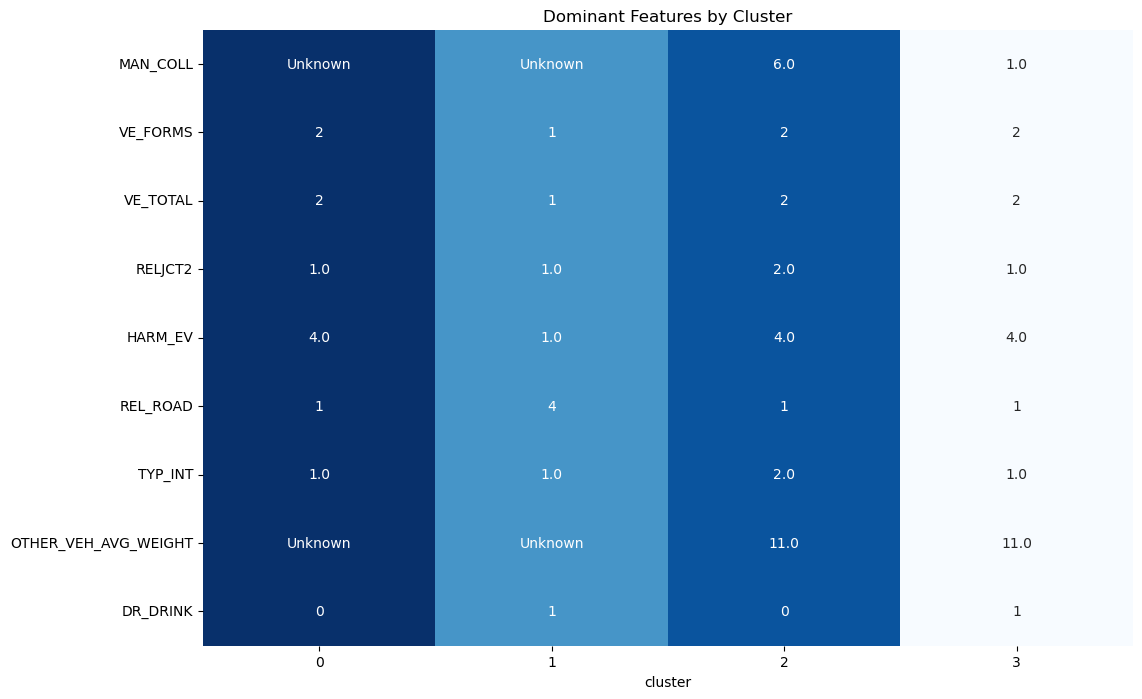

In [41]:
df_top_features = df_clean[['MAN_COLL', 'VE_FORMS', 'VE_TOTAL', 'RELJCT2', 'HARM_EV', 'REL_ROAD', 'TYP_INT', 'OTHER_VEH_AVG_WEIGHT', 'DR_DRINK', 'cluster']]

# 1. Calculate the Mode (most frequent value) for each cluster
# We use a lambda function to grab the top value from value_counts
cluster_modes = df_top_features.groupby('cluster').agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown").T

# 2. Create a table
# This highlights the differences immediately
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_top_features.groupby('cluster').count().T, # Simple count to visualize, or...
    annot=cluster_modes,             # ...annotate with the actual text values
    fmt="",                          # Tells seaborn the annotations are strings, not numbers
    cmap="Blues",                    # Color map (darker = more data, usually)
    cbar=False
)
plt.title("Dominant Features by Cluster")
plt.show()